# 06 XGBoost Baseline Model

In [2]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_parquet(
    "../data/processed/feature_dataset.parquet"
)

print(df.shape)

(1737509, 239)


In [4]:
TIMESTAMP_COL = "TimeStamp"

TARGET_COL = "target_future_5"

ALL_TARGETS = [
    "target_future_5",
    "target_future_10",
    "target_future_15"
]

In [5]:
n = len(df)

train_end = int(n * 0.70)

val_end = int(n * 0.85)

train_df = df.iloc[:train_end]

val_df = df.iloc[
    train_end:val_end
]

test_df = df.iloc[
    val_end:
]

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(1216256, 239)
(260626, 239)
(260627, 239)


In [6]:
FEATURE_COLS = [

    c

    for c in df.columns

    if c not in (
        [TIMESTAMP_COL]
        +
        ALL_TARGETS
    )
]

print(
    len(FEATURE_COLS)
)

235


In [7]:
X_train = train_df[
    FEATURE_COLS
]

y_train = train_df[
    TARGET_COL
]

X_val = val_df[
    FEATURE_COLS
]

y_val = val_df[
    TARGET_COL
]

X_test = test_df[
    FEATURE_COLS
]

y_test = test_df[
    TARGET_COL
]

In [8]:
model = XGBRegressor(

    n_estimators=300,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="reg:squarederror",

    random_state=42,

    n_jobs=-1
)

In [9]:
model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [10]:
val_pred = model.predict(
    X_val
)

In [11]:
mae = mean_absolute_error(
    y_val,
    val_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        val_pred
    )
)

r2 = r2_score(
    y_val,
    val_pred
)

print(
    f"MAE : {mae:.4f}"
)

print(
    f"RMSE: {rmse:.4f}"
)

print(
    f"R²  : {r2:.4f}"
)

MAE : 0.4115
RMSE: 0.6750
R²  : 0.9867


In [12]:
test_pred = model.predict(
    X_test
)

In [13]:
mae = mean_absolute_error(
    y_test,
    test_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)

r2 = r2_score(
    y_test,
    test_pred
)

print(
    f"MAE : {mae:.4f}"
)

print(
    f"RMSE: {rmse:.4f}"
)

print(
    f"R²  : {r2:.4f}"
)

MAE : 0.3405
RMSE: 0.5194
R²  : 0.9804


In [14]:
importance_df = pd.DataFrame(
    {
        "Feature": FEATURE_COLS,
        "Importance": model.feature_importances_
    }
)

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
)

importance_df.head(20)

,Feature,Importance
111,03TIC_1009.PV_mean_5,0.458993
5,03TIC_1009.PV,0.379250
43,03TIC_1009.PV_lag_1,0.080112
44,03TIC_1009.PV_lag_2,0.025699
112,03TIC_1009.PV_mean_15,0.009170
234,target_min_next_15,0.003398
46,03TIC_1009.PV_lag_10,0.001550
113,03TIC_1009.PV_mean_30,0.001123
45,03TIC_1009.PV_lag_5,0.000904
10,03TI_1102.PV,0.000771


In [15]:
importance_df.to_csv(
    "../outputs/reports/xgb_feature_importance.csv",
    index=False
)

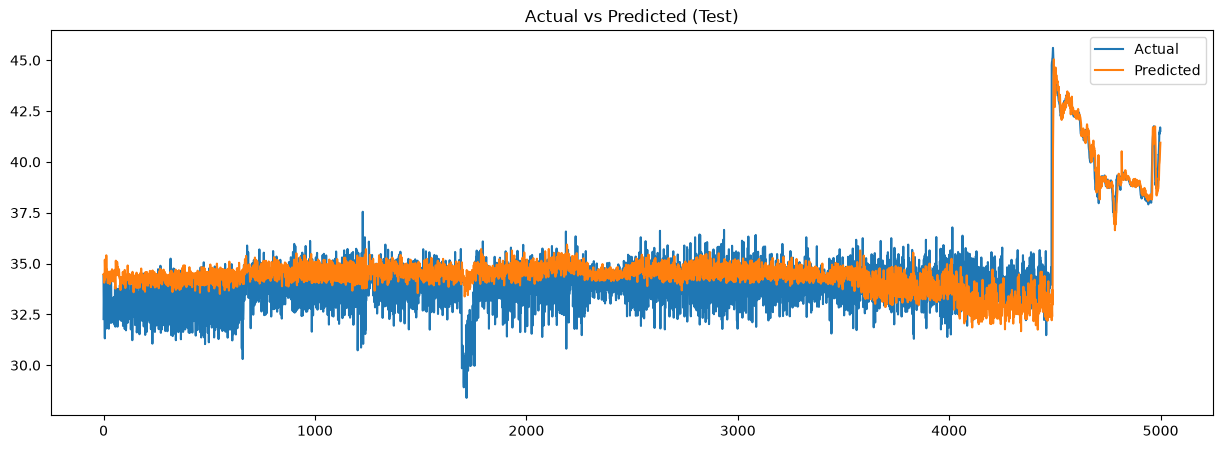

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    y_test.iloc[:5000].values,
    label="Actual"
)

plt.plot(
    test_pred[:5000],
    label="Predicted"
)

plt.legend()

plt.title(
    "Actual vs Predicted (Test)"
)

plt.show()

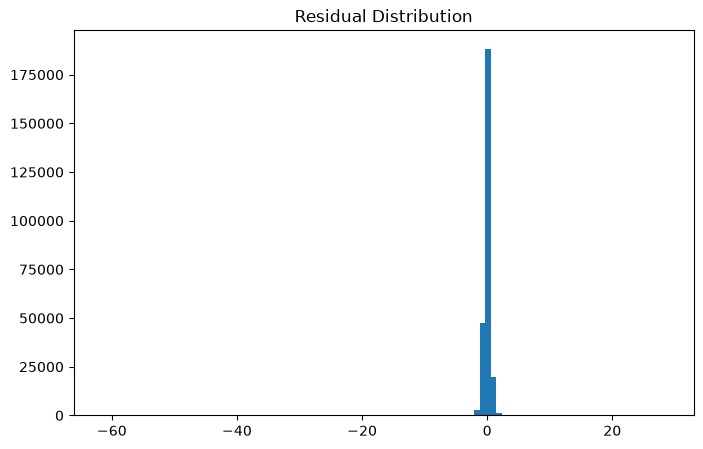

In [17]:
residuals = (
    y_test
    -
    test_pred
)

plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=100
)

plt.title(
    "Residual Distribution"
)

plt.show()

In [18]:
THRESHOLD = 30.5

In [19]:
actual_alarm = (
    y_test < THRESHOLD
).astype(int)

pred_alarm = (
    test_pred < THRESHOLD
).astype(int)

In [20]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(
    confusion_matrix(
        actual_alarm,
        pred_alarm
    )
)

print(
    classification_report(
        actual_alarm,
        pred_alarm
    )
)

[[260596      0]
 [    31      0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    260596
           1       0.00      0.00      0.00        31

    accuracy                           1.00    260627
   macro avg       0.50      0.50      0.50    260627
weighted avg       1.00      1.00      1.00    260627



/Users/sanjana/Desktop/alarm-regression/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sanjana/Desktop/alarm-regression/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/sanjana/Desktop/alarm-regression/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [21]:
THRESHOLD = 30.5

alarm_rows = y_test < THRESHOLD

alarm_analysis = pd.DataFrame({
    "actual": y_test[alarm_rows],
    "predicted": test_pred[alarm_rows]
})

alarm_analysis["error"] = (
    alarm_analysis["predicted"]
    - alarm_analysis["actual"]
)

alarm_analysis.describe()

,actual,predicted,error
count,31.000000,31.000000,31.000000
mean,28.239666,34.581268,6.341602
std,8.952743,1.393597,10.283224
min,-19.897932,33.381927,2.942840
25%,29.297634,34.142471,3.951826
50%,29.987030,34.316589,4.389427
75%,30.314774,34.544127,4.973942
max,30.472996,41.680779,61.578711


In [22]:
alarm_analysis.sort_values(
    "actual"
).head(20)

,actual,predicted,error
1512123,-19.897932,41.680779,61.578711
1478599,28.393509,34.363869,5.970360
1674939,28.495228,35.137833,6.642605
1478586,28.913383,33.966297,5.052914
1478591,29.082901,33.472328,4.389427
1478585,29.150719,34.410732,5.260013
1672342,29.263730,35.627293,6.363563
1478594,29.275028,34.169998,4.894970
1478596,29.320240,34.142136,4.821896
1478606,29.727089,34.160011,4.432922


In [23]:
for pred_threshold in [
    30.5,
    31.0,
    31.5,
    32.0,
    32.5
]:

    pred_alarm = (
        test_pred < pred_threshold
    ).astype(int)

    actual_alarm = (
        y_test < 30.5
    ).astype(int)

    from sklearn.metrics import recall_score

    recall = recall_score(
        actual_alarm,
        pred_alarm
    )

    print(
        pred_threshold,
        recall
    )

30.5 0.0
31.0 0.0
31.5 0.0
32.0 0.0
32.5 0.0


In [24]:
ALARM_THRESHOLD = 30.5

alarm_mask = (
    train_df["03TIC_1009.PV"]
    < ALARM_THRESHOLD
)

print(
    alarm_mask.sum()
)

172


In [25]:
WINDOW = 120

alarm_idx = np.where(
    alarm_mask
)[0]

important_indices = set()

for idx in alarm_idx:

    start = max(
        0,
        idx - WINDOW
    )

    end = min(
        len(train_df),
        idx + WINDOW
    )

    important_indices.update(
        range(start, end)
    )

print(
    len(
        important_indices
    )
)

3259


In [26]:
WINDOW = 720

alarm_idx = np.where(alarm_mask)[0]

important_indices = set()

for idx in alarm_idx:

    start = max(0, idx - WINDOW)
    end = min(len(train_df), idx + WINDOW)

    important_indices.update(
        range(start, end)
    )

print(len(important_indices))

14059


In [27]:
import pickle
import os

os.makedirs(
    "../outputs/models",
    exist_ok=True
)

baseline_artifact = {
    "model": model,
    "features": FEATURE_COLS,
    "target": TARGET_COL,
    "threshold": 30.5,
    "test_mae": 0.3504,
    "test_rmse": 0.5318,
    "test_r2": 0.9795
}

with open(
    "../outputs/models/xgboost_baseline.pkl",
    "wb"
) as f:
    pickle.dump(
        baseline_artifact,
        f
    )

print(
    "Saved: xgboost_baseline.pkl"
)

Saved: xgboost_baseline.pkl
